In [ ]:
# 04 — Классификатор-фильтр на касаниях уровней (зеркало pump-13 / dump-06)

nb02/03: среднее по касаниям = 0. Но среднее 0 ≠ «нет сигнала»: возможно часть
касаний разворачивается, часть прошивает, и причинные фичи их различают (в pump
дециль 0 был −2.35%, дециль 9 +2.49% при среднем +1.1%). Проверяем ровно это.

**Сетап (как dump-06):** события = касания cluster-уровней на всём периоде; ~21
причинная фича на баре касания (скорость r1..r24, signed-подход, ATR/rvol, RSI,
vsurge, позиция в диапазоне, dist_ma, форма свечи, сила уровня, сторона, тип
триггера); label = signed fwd-доходность за 12h. **Train = 2024, test = 2025-26.**
Модель = HistGradientBoostingRegressor (бустинг — та же «микро-модель», не NN:
на слабом сигнале робастнее сетки). Издержки COST=0.15% учитываем в оценке.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::3][:50]
START, END, TF = "2024-01-01", "2026-07-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; HLAB = 12; COST = 0.0015
SPLIT = pd.Timestamp("2025-01-01", tz="UTC")
print(len(UNIV), "symbols | label horizon", HLAB, "h | train<2025<=test")

47 symbols | label horizon 12 h | train<2025<=test


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    """Causal zones with strength (=#pivots). active [r, r+R)."""
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i + k, h[i]))
    for i in np.where(lo)[0]: conf.append((i + k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life); px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint: segs.append((float(np.mean(c)), r, min(r + R, n), len(c)))
    return segs

def candidate_touches(df, segs, tol=TOL):
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b, strg in segs:
        a = max(a, 1)
        for t in range(a, b):
            if c[t - 1] < L * (1 - tol) and h[t] >= L * (1 - tol):
                d = abs(h[t] - L) / L; key = (t, "res")
                if key not in best or d < best[key][1]: best[key] = (L, d, strg)
            elif c[t - 1] > L * (1 + tol) and l[t] <= L * (1 + tol):
                d = abs(l[t] - L) / L; key = (t, "sup")
                if key not in best or d < best[key][1]: best[key] = (L, d, strg)
    out = [(t, side, L, strg) for (t, side), (L, d, strg) in best.items()]
    out.sort(); kept = []; last = -10**9
    for t, side, L, strg in out:
        if t - last >= CD: kept.append((t, side, L, strg)); last = t
    return kept

In [3]:
FEATS = ["r1","r3","r6","r12","r24","ar6","ar12","rvol","atr","vsurge","rsi",
         "dist_hi","dist_lo","dist_ma","body","uwick","lwick","side","strength","is_wick","is_cbi"]

def feats(o, h, l, c, v, st, side, L, strg):
    def ret(k): return c[st] / c[st - k] - 1 if st - k >= 0 else np.nan
    r1, r3, r6, r12, r24 = ret(1), ret(3), ret(6), ret(12), ret(24)
    sgn = 1.0 if side == "res" else -1.0
    lr = np.diff(np.log(c[max(0, st - 24):st + 1])); rvol = lr.std() if len(lr) > 3 else np.nan
    atr = np.mean((h[st - 13:st + 1] - l[st - 13:st + 1]) / c[st - 13:st + 1])
    base = np.mean(v[max(0, st - 24):st]); vsurge = v[st] / base if base > 0 else np.nan
    d = np.diff(c[st - 14:st + 1]); up = d[d > 0].sum(); dn = -d[d < 0].sum()
    rsi = 100 - 100 / (1 + (up / 14) / ((dn / 14) + 1e-12))
    mx = h[max(0, st - 48):st + 1].max(); mn = l[max(0, st - 48):st + 1].min()
    ma = np.mean(c[max(0, st - 50):st + 1]); rng = max(h[st] - l[st], 1e-12)
    if side == "res":
        is_wick = float(c[st] < L * (1 - TOL) and c[st] <= l[st] + 0.33 * rng)
        is_cbi = float(h[st] > L * (1 + TOL) and c[st] < L)
    else:
        is_wick = float(c[st] > L * (1 + TOL) and c[st] >= h[st] - 0.33 * rng)
        is_cbi = float(l[st] < L * (1 - TOL) and c[st] > L)
    return dict(r1=r1, r3=r3, r6=r6, r12=r12, r24=r24, ar6=sgn * r6, ar12=sgn * r12,
                rvol=rvol, atr=atr, vsurge=vsurge, rsi=rsi,
                dist_hi=c[st] / mx - 1, dist_lo=c[st] / mn - 1, dist_ma=c[st] / ma - 1,
                body=(c[st] - o[st]) / rng, uwick=(h[st] - max(o[st], c[st])) / rng,
                lwick=(min(o[st], c[st]) - l[st]) / rng,
                side=1.0 if side == "res" else 0.0, strength=float(strg),
                is_wick=is_wick, is_cbi=is_cbi)

rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < 200: continue
    o = df["open"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    c = df["close"].to_numpy(); v = df["volume"].to_numpy(); ts = df.index; n = len(df)
    for t, side, L, strg in candidate_touches(df, cluster_segments(df)):
        if t < 60 or t + HLAB >= n: continue
        rr = c[t + HLAB] / c[t] - 1.0
        row = feats(o, h, l, c, v, t, side, L, strg)
        row.update(sym=sym, entry=ts[t], y=rr if side == "sup" else -rr)
        rows.append(row)
    if (si + 1) % 15 == 0: print(f"  {si+1}/{len(UNIV)}")

D = pd.DataFrame(rows).dropna().sort_values("entry").reset_index(drop=True)
print(f"\nevents: {len(D)} | base signed y: mean {D.y.mean()*100:+.3f}%  net {(D.y.mean()-COST)*100:+.3f}%  win {(D.y>0).mean()*100:.1f}%")

  15/47


  30/47


  45/47



events: 45373 | base signed y: mean -0.005%  net -0.155%  win 50.0%


In [4]:
tr = D[D.entry < SPLIT]; te = D[D.entry >= SPLIT].copy()
print(f"train {len(tr)} ({tr.entry.min():%Y-%m-%d}..{tr.entry.max():%Y-%m-%d}) | "
      f"test {len(te)} ({te.entry.min():%Y-%m-%d}..{te.entry.max():%Y-%m-%d})")
m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=400,
                                  l2_regularization=1.0, min_samples_leaf=50, random_state=0)
m.fit(tr[FEATS], tr.y)
te["pred"] = m.predict(te[FEATS])
corr = np.corrcoef(te.pred, te.y)[0, 1]
print(f"\nOOS corr(pred, actual y) = {corr:+.3f}")
te["dec"] = pd.qcut(te.pred, 10, labels=False, duplicates="drop")
g = te.groupby("dec").agg(n=("y","size"), mean_pct=("y", lambda s: s.mean()*100),
                          net_pct=("y", lambda s: (s.mean()-COST)*100), win=("y", lambda s: (s>0).mean()*100))
print("\n=== TEST deciles by predicted score (worst->best), net of", f"{COST*100:.2f}% ===")
print(g.round(3).to_string())

train 17774 (2024-01-07..2024-12-31) | test 27599 (2025-01-01..2026-04-30)



OOS corr(pred, actual y) = -0.014

=== TEST deciles by predicted score (worst->best), net of 0.15% ===
        n  mean_pct  net_pct     win
dec                                 
0    2760    -0.089   -0.239  50.109
1    2807    -0.050   -0.200  50.623
2    2716     0.012   -0.138  50.663
3    2929    -0.043   -0.193  49.573
4    2626     0.073   -0.077  51.066
5    3722     0.043   -0.107  50.376
6    2328     0.120   -0.030  50.344
7    2454    -0.037   -0.187  48.900
8    2497    -0.094   -0.244  48.138
9    2760    -0.080   -0.230  47.899


In [5]:
print("=== TEST: trade top-f by predicted score (net) ===")
sidx = np.argsort(-te.pred.to_numpy()); yv = te.y.to_numpy()
for f in [1.0, 0.5, 0.3, 0.15, 0.05]:
    k = max(1, int(len(yv) * f)); sel = yv[sidx[:k]]
    ms = sel.mean() / sel.std() if sel.std() > 0 else np.nan
    print(f"  top {int(f*100):>3}%: n={k:5d}  mean {sel.mean()*100:+.3f}%  net {(sel.mean()-COST)*100:+.3f}%  "
          f"win {(sel>0).mean()*100:.1f}%  m/std {ms:+.3f}")

=== TEST: trade top-f by predicted score (net) ===
  top 100%: n=27599  mean -0.014%  net -0.164%  win 49.8%  m/std -0.004
  top  50%: n=13799  mean -0.008%  net -0.158%  win 49.2%  m/std -0.002
  top  30%: n= 8279  mean -0.056%  net -0.206%  win 48.5%  m/std -0.015
  top  15%: n= 4139  mean -0.109%  net -0.259%  win 47.8%  m/std -0.026
  top   5%: n= 1379  mean -0.247%  net -0.397%  win 47.9%  m/std -0.052


[saved] notebooks\levels\_out\04_classifier.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/04_classifier.png')

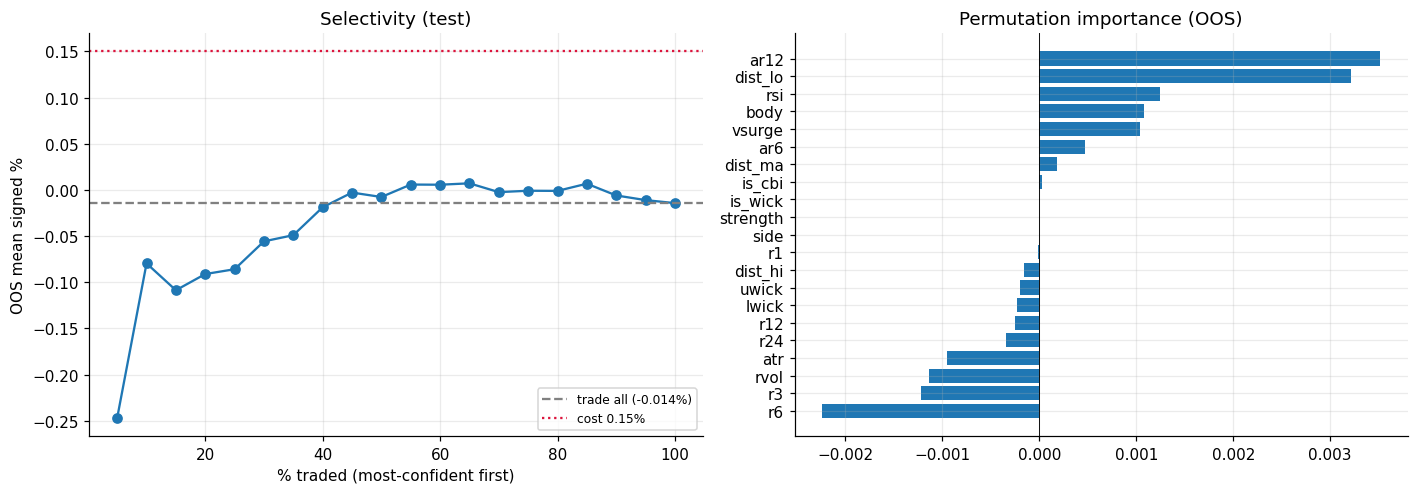

In [6]:
fracs = np.linspace(0.05, 1.0, 20); sidx = np.argsort(-te.pred.to_numpy()); yv = te.y.to_numpy()
means = [yv[sidx[:max(1,int(len(yv)*f))]].mean()*100 for f in fracs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(fracs*100, means, "o-"); a1.axhline(yv.mean()*100, color="gray", ls="--", label=f"trade all ({yv.mean()*100:+.3f}%)")
a1.axhline(COST*100, color="crimson", ls=":", label=f"cost {COST*100:.2f}%")
a1.set_xlabel("% traded (most-confident first)"); a1.set_ylabel("OOS mean signed %"); a1.set_title("Selectivity (test)"); a1.legend(fontsize=8)
imp = permutation_importance(m, te[FEATS], te.y, n_repeats=8, random_state=0, scoring="r2")
o2 = np.argsort(imp.importances_mean)
a2.barh([FEATS[i] for i in o2], imp.importances_mean[o2], color="tab:blue")
a2.set_title("Permutation importance (OOS)"); a2.axvline(0, color="k", lw=0.6)
show("04_classifier")

## Как читать / verdict

- **OOS corr > 0** + **монотонные децили** = фичи различают отскоки от пробоев даже
  при нулевом среднем. Монотонность важнее величины corr.
- **Selectivity**: если верхняя доля по pred устойчиво выше линии издержек — фильтр
  вытаскивает торгуемое подмножество из нулевого в среднем класса событий.
- Если и топ-дециль ≈ издержки — даже ML не находит edge → разворот-от-уровня
  опровергнут сильнее. Оговорка: один time-split (2024 vs 2025-26); тестовая эпоха
  иного режима. Дальше при успехе — walk-forward (как pump-14).